In [274]:
import pandas as pd
import spacy
import nltk
from nltk.corpus import stopwords, words
from sentence_transformers import SentenceTransformer
import numpy as np
from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel

In [275]:
df = pd.read_excel('../../../outputs/cluster_QID11_answer.xlsx', sheet_name='cluster_QID11_answer_with_a (2)')
df.head()

,Column1,user_id,cluster,ip,created_at,date,QID11_TEXT_translated,IP feature,QID11_answer_fature,same IP and similar answer,欄1,Other features,欄2
0,442,242385831,NaN,0.0.0.0,2023-12-12 16:32:19.771,NaN,NaN,Unknown IP,NaN,NaN,NaN,NaN,NaN
1,4432,102534225,NaN,0.0.0.0,2023-12-12 20:49:04.254,NaN,NaN,Unknown IP,NaN,NaN,NaN,NaN,NaN
2,1216,123,NaN,0.0.0.0,2023-12-13 08:53:40.147,NaN,NaN,Unknown IP,NaN,NaN,NaN,NaN,NaN
3,2231,619171083,NaN,0.0.0.0,2023-12-13 18:13:03.076,NaN,NaN,Unknown IP,NaN,NaN,NaN,NaN,NaN
4,4483,70443658,NaN,0.0.0.0,2023-12-15 17:51:21.645,NaN,NaN,Unknown IP,NaN,NaN,NaN,NaN,NaN


# Observation

## Users in clusters

In [276]:
user_in_clusters = df[~df['cluster'].isna()]
user_in_clusters.shape

(408, 13)

## Registering time

In [277]:
df['day'] = df['created_at'].dt.date
df['day'] = df['day'].astype(str).str.strip()

<Axes: xlabel='day'>

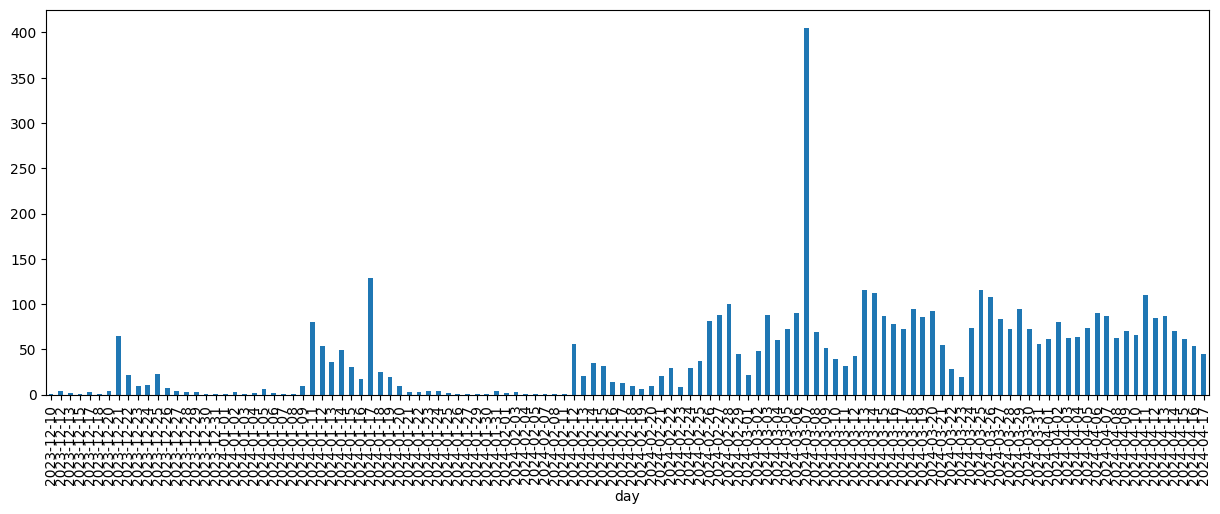

In [278]:
df.groupby('day')['user_id'].count().plot(kind='bar', figsize=(15, 5))

In [279]:
df[df['day'] == "2024-01-17"]

,Column1,user_id,cluster,ip,created_at,date,QID11_TEXT_translated,IP feature,QID11_answer_fature,same IP and similar answer,欄1,Other features,欄2,day
39,306,6819342705,cluster10,0.0.0.0,2024-01-17 18:36:25.889,NaN,NaN,Unknown IP,NaN,NaN,NaN,NaN,NaN,2024-01-17
49,343,6363844603,cluster11,0.0.0.0,2024-01-17 09:08:58.866,NaN,NaN,Unknown IP,NaN,NaN,NaN,NaN,NaN,2024-01-17
51,352,6554098614,cluster11,0.0.0.0,2024-01-17 21:08:49.244,NaN,NaN,Unknown IP,NaN,NaN,NaN,NaN,NaN,2024-01-17
363,1549,5391208421,NaN,0.0.0.0,2024-01-17 14:16:36.701,NaN,NaN,Unknown IP,NaN,NaN,NaN,NaN,NaN,2024-01-17
413,1793,5554579410,NaN,0.0.0.0,2024-01-17 12:40:37.789,NaN,NaN,Unknown IP,NaN,NaN,NaN,NaN,NaN,2024-01-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5003,344,691991934,cluster11,91.196.55.140,2024-01-17 11:30:21.180,2024-01-17 00:00:00,"Well, I am like this",same IP,NaN,NaN,NaN,NaN,NaN,2024-01-17
5007,361,6984930010,cluster11,188.163.114.145,2024-01-17 13:37:58.156,2024-01-17 00:00:00,wfwfw,same IP,Meaningless input,NaN,NaN,NaN,NaN,2024-01-17
5008,341,6013721077,cluster11,149.102.240.73,2024-01-17 08:52:30.660,2024-01-17 00:00:00,What about me?,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-17
5055,401,5755524587,cluster11,188.163.114.145,2024-01-17 17:58:31.160,2024-01-17 00:00:00,Y vpfizofavzhml famvLZH t waffles zfiamlho,same IP,Meaningless input,NaN,NaN,NaN,NaN,2024-01-17


# Generate label

Heuristic Rules:
1. All cluster users
2. Register time == 1/17, 3/7

## snorkel to generate weak lables

In [280]:
df.shape

(5070, 14)

In [281]:
# 定义标签常量
ABSTAIN = -1
POSITIVE = 1
NEGATIVE = 0

@labeling_function()
def if_from_clusters(x):
    if pd.isna(x['cluster']) == False:
        return POSITIVE
    else:
        return ABSTAIN
    
@labeling_function()
def if_specific_dates(x):
    if (x['day'] == "2024-01-17") or (x['day'] == "2024-03-07"):
        return POSITIVE
    else:
        return ABSTAIN

@labeling_function()
def if_whitelist_user(x):
    whitelist_users = {508864913, 1443724814, 438261621, 954129196}
    if x['user_id'] in whitelist_users:
        return NEGATIVE
    else:
        return ABSTAIN

@labeling_function()
def if_contains_whitelist_words(x):
    whitelist_words = {'war', 'invasion'}
    if any(word in str(x['QID11_TEXT_translated']) for word in whitelist_words):
        return NEGATIVE
    else:
        return ABSTAIN


In [282]:
# lfs = [if_from_clusters, if_specific_dates, if_whitelist_user, if_contains_whitelist_words]
# applier = PandasLFApplier(lfs=lfs)
# L_train = applier.apply(df=df)
# LFAnalysis(L=L_train, lfs=lfs).lf_summary()
# label_model = LabelModel(cardinality=2, verbose=True)  # cardinality=2 表示二分类
# label_model.fit(L_train=L_train, n_epochs=500, log_freq=50, seed=42)
# df['prob_label'] = label_model.predict_proba(L=L_train)[:, 1]  # 获取正类的概率
# df['weak_label'] = label_model.predict(L=L_train)  # 获取最终的弱标签

## Manually set label

In [283]:
def generate_label(row):
    whitelist_users = {508864913, 1443724814, 438261621, 954129196}
    whitelist_words = {'war', 'invasion'}
    if pd.isna(row['cluster']) == False:
        return 1
    elif (row['day'] == "2024-01-17") or (row['day'] == "2024-03-07"):
        return 1
    elif row['user_id'] in whitelist_users:
        return 0
    elif any(word in str(row['QID11_TEXT_translated']) for word in whitelist_words):
        return 0
    else:
        return -1

df['weak_label'] = df.apply(generate_label, axis=1)
df['weak_label'].value_counts()

weak_label
-1    4112
 1     847
 0     111
Name: count, dtype: int64

In [264]:
df[df['weak_label'] == 0]

,Column1,user_id,cluster,ip,created_at,date,QID11_TEXT_translated,IP feature,QID11_answer_fature,same IP and similar answer,欄1,Other features,欄2,day,prob_label,weak_label
5021,2964,508864913,NaN,194.44.70.145,2024-03-11 15:28:53.850,Why repeat the question but in a different form?,Why repeat the question but in a different form?,NaN,NaN,NaN,NaN,NaN,white list,2024-03-11,0.496433,0


# Preprocessing

In [206]:
df = df[['user_id', 'QID11_TEXT_translated', 'QID11_answer_fature', 'bot']]
df = df[df['QID11_TEXT_translated'].isna() == False]
df['bot'].value_counts()

bot
0    3538
1     644
Name: count, dtype: int64

1. 文本清理：

* 去除多余的空格、特殊字符、HTML 标签等。
* 将文本转换为小写（如果大小写不重要）。

2. 分词：

* 使用 SpaCy 将文本分割为单词或标记。

3. 去停用词：

* 去除常见的无意义词（如 "the", "is", "and" 等）。

4. 词形还原（Lemmatization）：

* 将单词还原为其基本形式（如 "running" → "run"）。

5. 去除标点符号：

* 删除标点符号（如果不需要保留）。

6. 去除数字：

* 删除数字（如果数字对分析无意义）。

7. 自定义过滤：

* 根据项目需求，去除特定的词或符号。

In [217]:
nlp = spacy.load('en_core_web_sm')
nltk.download('words')
english_words = set(words.words())
model = SentenceTransformer('all-MiniLM-L6-v2') 
print("Model loaded successfully!")

[nltk_data] Downloading package words to
[nltk_data]     C:\Users\hydon\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
c:\Users\hydon\anaconda3\envs\nlp\Lib\site-packages\huggingface_hub\file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hydon\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/

Model loaded successfully!


In [208]:
def preprocess_text(text):
    doc = nlp(text)
    whitelist = {"nothing", "never", "nowhere", "nobody", "empty",
                 "who", "whom", "whose", "what", "which", "why", "how"}
    tokens = []
    for token in doc:
        # 保留否定词及其相关词
        if token.dep_ == 'neg':
            tokens.append("not")
        # 保留主语类词、数字和其他重要词
        elif (
            token.text.lower() in whitelist  # 白名单
            or token.dep_ in {"nsubj", "nsubjpass", "csubj", "csubjpass"}  # dependency parsing
            or token.pos_ in {"NOUN", "PROPN", "VERB", "ADJ", "ADV"}  # part-of-speech tagging
            or not token.is_stop  # 非停用词
            or token.like_num  # 数字
        ):
            tokens.append(token.lemma_.lower())

    
    return " ".join(tokens)

In [209]:
df['QID11_TEXT_tokenized'] = df['QID11_TEXT_translated'].apply(preprocess_text)
df.head()

,user_id,QID11_TEXT_translated,QID11_answer_fature,bot,QID11_TEXT_tokenized
888,555670720,"""You know that you are a person"".. I like to t...",NaN,0,""" you know you person "" .. i like travel , esp..."
889,6083358860,. ...trl,Meaningless input,1,. ... trl
890,556367481,"... I don't even know, I'm friendly",NaN,0,"... i not even know , i friendly"
891,670673425,000,Meaningless input,0,000
892,372440111,1,Meaningless input,0,1


In [210]:
df.shape

(4182, 5)

In [211]:
df[df['user_id'] == 1036581790]['QID11_TEXT_tokenized'].values

array(['calm , rational person who try develop critical thinking . i take responsibility work try do well time . i not quite understand what kind activity we talk , so i will not answer .'],
      dtype=object)

In [212]:
effective_token_length = 6
def is_in_english_words(text):
    return text.lower() in english_words

In [218]:
df_copy = df.copy()

df_copy = df_copy[df_copy['QID11_TEXT_tokenized'].notna()]
df_copy = df_copy[(df_copy['QID11_TEXT_tokenized'].str.strip().str.len() >= effective_token_length) | (df_copy['QID11_TEXT_tokenized'].apply(is_in_english_words))]
# word embedding
df_copy['QID11_TEXT_embedding'] = df_copy['QID11_TEXT_tokenized'].apply(lambda x: model.encode(x))
# 如果需要将嵌入结果转换为 NumPy 数组
# embeddings = np.vstack(df_copy['QID11_TEXT_embedding'].values)

In [219]:
df_copy[df_copy['QID11_TEXT_tokenized'].str.strip().str.len() <= 6]

,user_id,QID11_TEXT_translated,QID11_answer_fature,bot,QID11_TEXT_tokenized,QID11_TEXT_embedding
965,6134379781,A pedant,NaN,0,pedant,"[0.029413532, -0.029461613, 0.031434007, -0.02..."
1052,587341353,Active,NaN,0,active,"[-0.015728623, -0.07649323, -0.059274476, 0.07..."
1053,557673138,Active,NaN,0,active,"[-0.015728623, -0.07649323, -0.059274476, 0.07..."
1083,5976654674,All OK,NaN,1,all ok,"[-0.039820828, -0.11707373, -0.005575859, -0.0..."
1084,455410603,All OK,NaN,1,all ok,"[-0.039820828, -0.11707373, -0.005575859, -0.0..."
...,...,...,...,...,...,...
5008,6013721077,What about me?,NaN,1,what ?,"[-0.101225466, -0.01859407, -0.041910507, -0.0..."
5026,5184700495,woman,NaN,0,woman,"[-0.04559169, 0.011334597, -0.019113092, 0.044..."
5028,1148516787,Work,NaN,0,work,"[-0.13437359, 0.074107, 0.03603969, -0.0155145..."
5050,5673183954,Working,NaN,0,work,"[-0.13437359, 0.074107, 0.03603969, -0.0155145..."


In [232]:
len(df_copy[['QID11_TEXT_embedding']].iloc[0, :].values[0])

384